In [37]:
import torch

PyTorch具有一个内置的微分引擎torch.autograd以支持计算图的梯度自动计算
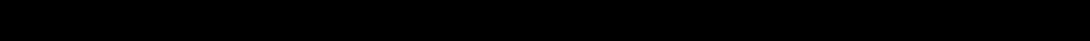

In [38]:
# 定义数据
x = torch.tensor(10.0)
y = torch.tensor([[3.0]])
print(x)
print(y)

tensor(10.)
tensor([[3.]])


In [39]:
# 初始化参数
w = torch.rand(1, 1, requires_grad=True)
b = torch.rand(1, 1, requires_grad=True)
print(w)
print(b)

tensor([[0.8315]], requires_grad=True)
tensor([[0.5622]], requires_grad=True)


In [40]:
# 前向传播，得到输出
z = w * x + b
print(z)

tensor([[8.8776]], grad_fn=<AddBackward0>)


In [41]:
# 判断是否是叶子节点，叶子节点的数据不是由计算生成的，叶子节点张量不能做 in-place 操作（原地操作）
print(x.is_leaf)
print(y.is_leaf)
print(w.is_leaf)
print(b.is_leaf)
print(z.is_leaf)

True
True
True
True
False


自动微分的关键就是记录节点的数据与运算。数据记录在张量的data属性中，计算记录在张量的grad_fn属性中。

计算图根据搭建方式可分为静态图和动态图，PyTorch是动态图机制，在计算的过程中逐步搭建计算图，同时对每个 Tensor 都存储 grad_fn 供自动微分使用。

若设置张量参数requires_grad=True，则PyTorch会追踪所有基于该张量的操作，并在反向传播时计算其梯度。依赖于叶子节点的节点，requires_grad默认为True。当计算到根节点后，在根节点调用backward()方法即可反向传播计算计算图中所有节点的梯度。

非叶子节点的梯度在反向传播之后会被释放掉（除非设置参数retain_grad=True）。而叶子节点的梯度在反向传播之后会保留（累积）。通常需要使用optimizer.zero_grad()清零参数的梯度。


In [42]:
# 设置损失函数
loss = torch.nn.MSELoss()
loss_value = loss(z, y)
print(loss_value)
print(loss_value.is_leaf)

tensor(34.5458, grad_fn=<MseLossBackward0>)
False


In [43]:
# 反向传播
loss_value.backward()

In [44]:
# 查看梯度
print(w.grad)
print(b.grad)

tensor([[117.5513]])
tensor([[11.7551]])
